# Prerequisites

### Modules

In [1]:
# Modules are available in conda environment with name: kmc_cathode
# conda activate kmc_cathode
#test
import ase
from ase.io import read as ASEread
from ase.io.vasp import write_vasp
from ase.db import connect
from ase.cell import Cell
from ase.neighborlist import NewPrimitiveNeighborList
from ase.build import make_supercell

import numpy as np
import pandas as pd
import scipy
import sklearn
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import colormaps
import glob
import sys
import os
import random
import shutil

import icet
from icet import ClusterSpace, StructureContainer, ClusterExpansion
from trainstation import CrossValidationEstimator
from icet.tools import enumerate_structures
from icet.tools.structure_generation import generate_sqs_by_enumeration

try:
    import seaborn as sns
    sns.set_context('notebook')
except ImportError:
    print('sad')
    
import subprocess

import datetime
import time as pytime

### Misc Functions

In [2]:
# Stop message
def jupyter_stop(ErrorMessage="User-defined stop via jupyter_stop() function"):
    """
    User defined stop function, similar to exit(). Mostly for testing purpose or to 
    avoid overwriting of already generated data.
    """
    raise SystemExit(ErrorMessage)

### reading cluster expansion

In [3]:
filename_cluster_expansion = 'mixing_energy_anchorTS_lasso.ce'

path_cluster_expansion = os.path.join(os.path.abspath(os.getcwd()), filename_cluster_expansion)
print(path_cluster_expansion)
ce = icet.ClusterExpansion.read(path_cluster_expansion)

/nfshome/winkelmann/ARL/vs_jupyter_for_ARL/jupyter_for_ARL/mixing_energy_anchorTS_lasso.ce


# creating hull data

In [ ]:
# create random structures and predict their energies
species = ['Li', 'X']
data = {'concentration': [], 'mixing_energy': []}
structures = []
cluster_space = ce.get_cluster_space_copy()
chemical_symbols = cluster_space.chemical_symbols
print(f'chemical symbols: {chemical_symbols}')
primitive_structure = cluster_space.primitive_structure

for structure in enumerate_structures(structure=primitive_structure,
                                      sizes=range (1, 12),
                                      chemical_symbols=chemical_symbols):
    if structure.symbols.count('Ti') != 0:
        continue
    no_Li = structure.symbols.count('Li')
    no_Vac = structure.symbols.count('X')
    concentration = no_Li / (no_Li + no_Vac)
    data['concentration'].append(concentration)
    data['mixing_energy'].append(ce.predict(structure))
    structures.append(structure)

       
print(f'Predicted energies for {len(structures)} structures')

data['mixing_energy'] = np.array(data['mixing_energy']) * 1e3

hull = icet.tools.ConvexHull(data['concentration'], data['mixing_energy'])
for concentration, energy in zip(hull.concentrations, hull.energies):
    print(f'Concentration: \t {concentration:e}, Energy: \t {energy:e}')

### save hull data

In [10]:
import pickle

checkpoint_file = 'hull_checkpoint.pkl'

checkpoint = {'data': data, 'structures': structures, 'hull': hull}
with open(checkpoint_file, 'wb') as f:
    pickle.dump(checkpoint, f)
print(f'✓ Saved results to {checkpoint_file}')

✓ Saved results to hull_checkpoint.pkl


# printing structureses and plots

### read hull data

In [4]:
import pickle

checkpoint_file = 'hull_checkpoint.pkl'

with open(checkpoint_file, 'rb') as f:
    checkpoint = pickle.load(f)
    data = checkpoint['data']
    structures = checkpoint['structures']
    hull = checkpoint['hull']
print(f'Loaded {len(structures)} structures')
print(f'Concentrations: {len(data["concentration"])}')
print(f'Mixing energies: {len(data["mixing_energy"])}')

Loaded 9504 structures
Concentrations: 9504
Mixing energies: 9504


### exporting hull structures

In [5]:
hull_structures = []
concs = data['concentration']
energies = data['mixing_energy']
for conc, energy in zip(hull.concentrations, hull.energies):
    idx = np.where(np.isclose(concs, conc, atol=1e-8) &
                   np.isclose(energies, energy, atol=1e-6))[0]
    if len(idx) == 0:
        idx = np.argmin(np.abs(np.array(concs) - conc) +
                        np.abs(np.array(energies) - energy))
        idx = [idx]
    hull_structures.append(structures[idx[0]])
    print(f'Hull vertex: conc={conc:.4f}, energy={energy:.6f}, index={idx[0]}')
    write_vasp(f'hull_structure_{conc:.4f}.vasp', structures[idx[0]], direct=True)

Hull vertex: conc=0.0000, energy=2.860770, index=1
Hull vertex: conc=0.2500, energy=-20.236183, index=47
Hull vertex: conc=0.4000, energy=-27.060322, index=58
Hull vertex: conc=0.5000, energy=-29.398342, index=3
Hull vertex: conc=0.7500, energy=-21.605119, index=46
Hull vertex: conc=1.0000, energy=2.189601, index=0


### plotting the hull

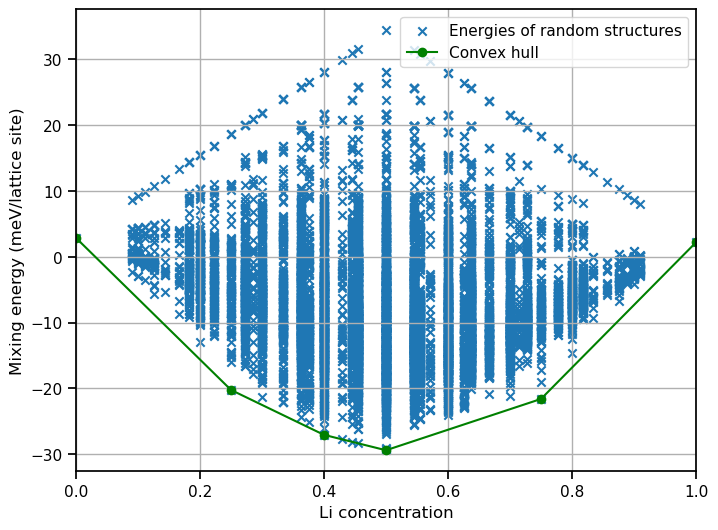

In [6]:
# with all random structures created
fig, ax = plt.subplots(figsize=(8, 6))
ax.grid(True)
ax.set_xlabel(r'Li concentration')
ax.set_ylabel(r'Mixing energy (meV/lattice site)')
ax.set_xlim([0, 1])
ax.scatter(data['concentration'], data['mixing_energy'], marker='x')
ax.plot(hull.concentrations, hull.energies, '-o', color='green')
ax.legend(['Energies of random structures', 'Convex hull'])
plt.show()

### with average of rnd start structures

In [7]:
# Read the CSV file containing energies of randomized structures
filename_energy_of_rnd_structures = '~/Simulations/CathodeSimulationResults/energy_of_rnd_start-structures/kmc_Cathode_energy_of_randomized_structures.csv'
# Use os.path.expanduser to expand '~' to the full home directory path.
path_energy_of_rnd_structures = os.path.expanduser(filename_energy_of_rnd_structures)
data_rnd = pd.read_csv(path_energy_of_rnd_structures)
data_rnd.columns = data_rnd.columns.str.replace('\t', '') #getting rid of tab characters in column names
data_rnd.columns = data_rnd.columns.str.replace(' ', '') #getting rid of whitespace characters in column names
# Calculate concentration as 1-(vacancy_content/100)
if 'vacancy_content' in data_rnd.columns:
    data_rnd['concentration'] = 1 - (data_rnd['vacancy_content'] / 100)
    print("Added concentration column based on vacancy content")
else:
    print("Warning: 'vacancy_content' column not found in data_rnd")
    # List available columns for reference
    print("Available columns:", data_rnd.columns.tolist())
print(data_rnd)

Added concentration column based on vacancy content
   vacancy_content  runs  energy_avg[meV/atom]  std_dev[meV/atom]  \
0             87.5   100             -0.216957           0.128877   
1             75.0   100             -4.400812           0.250958   
2             67.0   100             -6.924483           0.290989   
3             60.0   100             -8.581716           0.390376   
4             54.0   100             -9.602340           0.406824   
5             50.0   100             -9.969772           0.403787   
6             37.5   100             -9.783903           0.326095   
7             25.0   100             -7.240112           0.232215   
8             12.5   100             -2.941733           0.101038   

   concentration  
0          0.125  
1          0.250  
2          0.330  
3          0.400  
4          0.460  
5          0.500  
6          0.625  
7          0.750  
8          0.875  


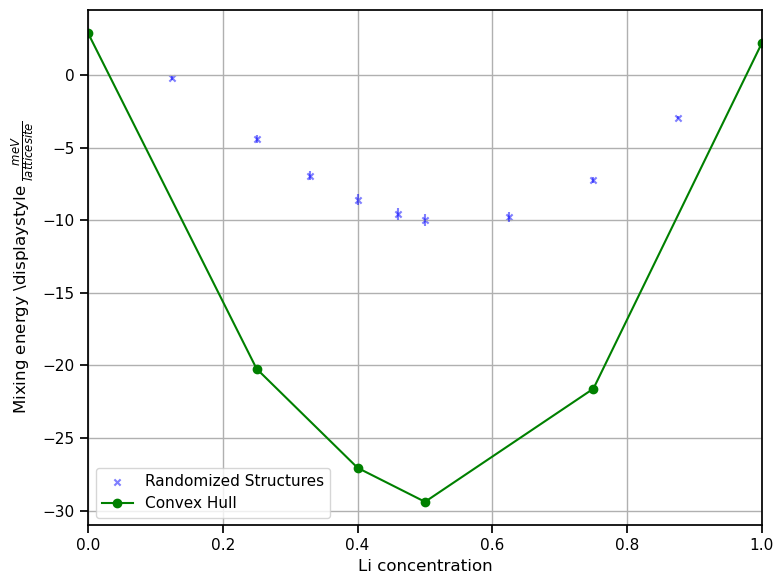

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
# adding avg of rnd structures
ax = data_rnd.plot.scatter(x='concentration', y='energy_avg[meV/atom]', yerr='std_dev[meV/atom]', marker='x',
                        ax=ax, color='blue', label='Randomized Structures', alpha=0.5)
# adding hull
ax.plot(hull.concentrations, hull.energies, '-o', color='green', label='Convex Hull')
ax.grid(True)
ax.set_xlabel(r'Li concentration')
ax.set_ylabel(r'Mixing energy \displaystyle $\frac{meV}{lattice site}$')
ax.set_xlim([0, 1])
ax.legend()
plt.tight_layout()
plt.savefig(filename_cluster_expansion.replace('.ce', '_hull_and_rnd-structures.png'), bbox_inches='tight')